## Úloha 1: Nepodmíněná optimalizace

Nakreslete graf a vrstevnice funkce:
$$f(x_1, x_2) = (x_1 - x_2^2)^2 + 100(1 - x_1)^2$$


Řešte úlohu optimalizace bez omezení:
$$\min_{x \in \mathbb{R}^2} f(x_1, x_2)$$

Tuto úlohu řešte metodou největšího spádu, Newtonovou metodou s analyticky vypočteným gradientem 
i Hessiánem, Newtonovou metodou s numericky vypočteným gradientem i Hessiánem, BFGS
metodou a Trust region metodou. Porovnejte rychlost konvergence (tj. počty iterací) a počty vyčís-
lení minimalizované funkce při použití jednotlivých metod. Úlohy počítejte s ukončující podmínkou
na velikost gradientu i délku kroku.

### Analytický výpočet $\nabla f$ a $\nabla^2 f$
Nechť
$$f(x_1,x_2)=(x_1-x_2^2)^2+100(1-x_1)^2 = x_1^2 - 2x_1x_2^2 + x_2^4 + 100(1-2x_1+x_1^2).$$
Pak
$$\frac{\partial f}{\partial x_1}=2x_1-2x_2^2+200x_1-200,$$
$$\frac{\partial f}{\partial x_2}=-4x_1x_2+4x_2^3.$$
Tedy
$$\nabla f(x_1,x_2)=\begin{pmatrix}2x_1-2x_2^2+200x_1-200\\-4x_1x_2+4x_2^3\end{pmatrix}.$$
Dále
$$\frac{\partial^2 f}{\partial x_1^2}=\frac{\partial}{\partial x_1}(2x_1-2x_2^2+200x_1-200)=202,$$
$$\frac{\partial^2 f}{\partial x_1\partial x_2}=\frac{\partial}{\partial x_2}(2x_1-2x_2^2+200x_1-200)=-4x_2,$$
$$\frac{\partial^2 f}{\partial x_2\partial x_1}=\frac{\partial}{\partial x_1}(-4x_1x_2+4x_2^3)=-4x_2,$$
$$\frac{\partial^2 f}{\partial x_2^2}=\frac{\partial}{\partial x_2}(-4x_1x_2+4x_2^3)=-4x_1+12x_2^2.$$
Tedy
$$\nabla^2 f(x_1,x_2)=\begin{pmatrix}202 & -4x_2\\-4x_2 & -4x_1+12x_2^2\end{pmatrix}.$$

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def fun(x):
    x1, x2 = x
    return (x1 - x2**2)**2 + 100.0 * (1.0 - x1)**2

def grad_f(x):
    x1, x2 = x
    return np.array([
        2*x1 - 2*x2**2 + 200*x1 - 200,
        -4*x1*x2 + 4*x2**3,
    ], dtype=float)

def hess_f(x):
    x1, x2 = x
    return np.array([
        [202.0, -4.0 * x2],
        [-4.0 * x2, -4.0 * x1 + 12.0 * x2**2],
    ], dtype=float)

# Pomocna trida pro pocitani volani funkce
class Counter:
    def __init__(self, fun):
        self.fun = fun
        self.n = 0
    def __call__(self, x):
        self.n += 1
        return self.fun(np.asarray(x, dtype=float))
    def reset(self):
        self.n = 0


### Centrální diference pro numerický výpočet Hessiánu

Nechť $e_i$ je $i$-tý sloupec jednotkové matice a $\varepsilon>0$ je malé číslo.

**Gradient (centrální diference):**

$$\frac{\partial f}{\partial x_i}(x^k) \approx \frac{f(x^k+\varepsilon e_i)-f(x^k-\varepsilon e_i)}{2\varepsilon}.$$

**Hessián (centrální diference přímo z $f$):**

- Diagonální prvky ($i=j$):

$$\frac{\partial^2 f}{\partial x_i^2}(x) \approx \frac{f(x+\varepsilon e_i)-2f(x)+f(x-\varepsilon e_i)}{\varepsilon^2}.$$

- Smíšené derivace ($i\neq j$):

$$\frac{\partial^2 f}{\partial x_i\partial x_j}(x) \approx
\frac{f(x+\varepsilon e_i+\varepsilon e_j)-f(x+\varepsilon e_i-\varepsilon e_j)-f(x-\varepsilon e_i+\varepsilon e_j)+f(x-\varepsilon e_i-\varepsilon e_j)}{4\varepsilon^2}.$$


In [34]:
# Numericky vypocet gradientu a Hessianu s pouzitim centralnich diferenci
def num_grad(fun, x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    n = x.size
    g = np.zeros(n)
    for i in range(n):
        e = np.zeros(n)
        e[i] = 1.0
        g[i] = (fun(x + eps * e) - fun(x - eps * e)) / (2.0 * eps)
    return g

def num_hess(fun, x, eps=1e-4):
    x = np.asarray(x, dtype=float)
    n = x.size
    H = np.zeros((n, n))
    fx = fun(x)
    for i in range(n):
        ei = np.zeros(n)
        ei[i] = 1.0
        H[i, i] = (fun(x + eps * ei) - 2.0 * fx + fun(x - eps * ei)) / (eps**2)
        for j in range(i + 1, n):
            ej = np.zeros(n)
            ej[j] = 1.0
            H[i, j] = (fun(x + eps * ei + eps * ej) - fun(x + eps * ei - eps * ej) - fun(x - eps * ei + eps * ej) +  fun(x - eps * ei - eps * ej)) / (4.0 * eps**2)
            # symetrie
            H[j, i] = H[i, j]
    return H

### Graf a vrstevnice

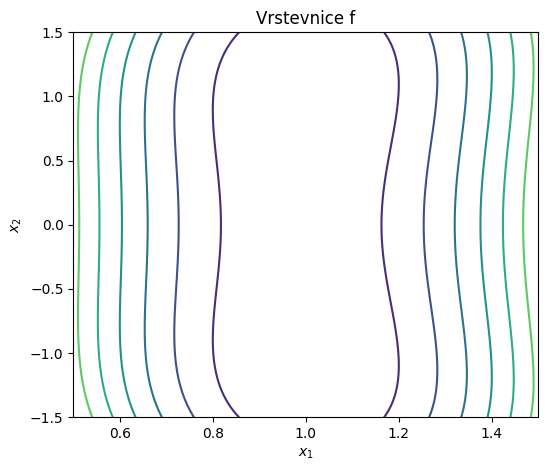

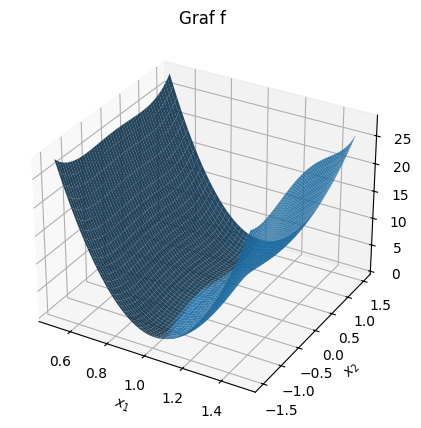

In [35]:
x1 = np.linspace(0.5, 1.5, 401)
x2 = np.linspace(-1.5, 1.5, 401)
X1, X2 = np.meshgrid(x1, x2)
Z = (X1 - X2**2)**2 + 100.0 * (1.0 - X1)**2

plt.figure(figsize=(6, 5))
plt.contour(X1, X2, Z)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Vrstevnice f")
plt.show()

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, Z, rstride=8, cstride=8, linewidth=0, antialiased=True, alpha=0.9)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel("f")
ax.set_title("Graf f")
plt.show()

### Optimalizace (největší spád, Newton, numerický Newton, BFGS, Trust region)

In [36]:
# line search using Armijo condition
def find_alpha(fun, x, p, g, alpha0=1.0, c1=1e-4, tau=0.5, max_ls=50):
    x = np.asarray(x, dtype=float)
    fx = fun(x)
    gp = float(np.dot(g, p))
    alpha = float(alpha0)
    for _ in range(max_ls):
        if fun(x + alpha * p) <= fx + c1 * alpha * gp:
            return alpha
        alpha *= tau
    return alpha

def steepest_descent(fun, grad, x0, tol_g=1e-6, tol_step=1e-9, max_iter=20000):
    x = np.asarray(x0, dtype=float)
    # data for final graph
    hist = {"f": [], "gn": []}
    for _ in range(max_iter):
        g = grad(x)
        g_norm = float(np.linalg.norm(g))
        fx = fun(x)
        hist["f"].append(fx)
        hist["gn"].append(g_norm)
        # gradient check
        if g_norm <= tol_g:
            break
        # p is step direction
        p = -g
        # alpha is step size
        alpha = find_alpha(fun, x, p, g)
        s = alpha * p
        # step size check
        if float(np.linalg.norm(s)) <= tol_step:
            x = x + s
            break
        x = x + s
    return x, hist

def newton(fun, grad, hess, x0, tol_g=1e-6, tol_step=1e-9, max_iter=200):
    x = np.asarray(x0, dtype=float)
    hist = {"f": [], "gn": []}
    for _ in range(max_iter):
        g = grad(x)
        g_norm = float(np.linalg.norm(g))
        fx = fun(x)
        hist["f"].append(fx)
        hist["gn"].append(g_norm)
        if g_norm <= tol_g:
            break
        H = hess(x)
        try:
            d = -np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            d = -g
        if float(np.dot(g, d)) >= 0.0:
            d = -g
        alpha = find_alpha(fun, x, d, g)
        s = alpha * d
        if float(np.linalg.norm(s)) <= tol_step:
            x = x + s
            break
        x = x + s
    return x, hist

def bfgs(fun, grad, x0, tol_g=1e-6, tol_step=1e-9, max_iter=1000):
    x = np.asarray(x0, dtype=float)
    n = x.size
    H = np.eye(n)
    hist = {"f": [], "gn": []}
    g = grad(x)
    for _ in range(max_iter):
        g_norm = float(np.linalg.norm(g))
        fx = fun(x)
        hist["f"].append(fx)
        hist["gn"].append(g_norm)
        if g_norm <= tol_g:
            break

        # newtonuv krok
        try:
            p = -np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            p = -g
            H = np.eye(n)

        if float(np.dot(g, p)) >= 0.0:
            p = -g
            H = np.eye(n)

        alpha = find_alpha(fun, x, p, g)
        s = alpha * p
        if float(np.linalg.norm(s)) <= tol_step:
            x = x + s
            break
        x_new = x + s
        g_new = grad(x_new)
        y = g_new - g
        sy = float(np.dot(s, y))

        if sy > 1e-12:
            Hs = H @ s
            sH = s.T @ H
            sHs = float(np.dot(s, Hs))
            H = H + np.outer(y, y) / sy - np.outer(Hs, sH) / sHs

        x, g = x_new, g_new
    return x, hist

In [37]:
from scipy.optimize import minimize
def trust_region(fun, grad, hess, x0, tol_g=1e-6, tol_step=1e-9, max_iter=500, c0=1.0, c_max=100.0, eta1=0.1, eta2=0.75, gamma1=0.25, gamma2=2.0):
    x = np.array(x0, dtype=float)
    c_k = c0  #  current trust region radius
    k = 0
    hist = {"f": [], "gn": []} 

    while np.linalg.norm(grad(x)) >= tol_g and k < max_iter:
        g = grad(x)
        H = hess(x)
        fx = fun(x)
        
        # quadratic model m_k(d)
        def model_m(d):
            return fx + np.dot(g, d) + 0.5 * np.dot(d, np.dot(H, d))
        
        # constraint: ||d|| <= c_k
        cons = ({'type': 'ineq', 'fun': lambda d: c_k - np.linalg.norm(d)})
        
        # finding step d_k by minimizing the model m_k(d) subject to the trust region constraint
        d0 = np.zeros_like(x)
        res = minimize(model_m, d0, method='SLSQP', constraints=cons)
        d_k = res.x
        
        if np.linalg.norm(d_k) < tol_step:
            break
            
        # calculate rho_k
        pred_reduction = fx - model_m(d_k)
        actual_reduction = fx - fun(x + d_k)
        
        if pred_reduction < 1e-12:
            rho_k = 0.0
        else:
            rho_k = actual_reduction / pred_reduction
            
        # update the trust region radius (c_k)
        if rho_k < eta1:
            c_k = gamma1 * c_k
        elif rho_k > eta2:
            c_k = min(c_max, gamma2 * c_k)
        
        # accept or reject the step
        if rho_k >= eta1:
            x = x + d_k
            
        k += 1
        hist["f"].append(fun(x))
        hist["gn"].append(np.linalg.norm(grad(x)))
        
    return x, hist

x0 = [-1.2  1. ]
Steepest descent  it= 158  n_f_calls=  1531  f=2.106e-14  ||g||=7.550e-07  x=[1.         0.99999993]
Newton (analytical)  it=   1  n_f_calls=     4  f=4.930e-30  ||g||=5.684e-14  x=[1. 1.]
Newton (numerical)  it=   2  n_f_calls=    37  f=9.951e-25  ||g||=3.090e-14  x=[1. 1.]
BFGS              it=   6  n_f_calls=    29  f=9.310e-20  ||g||=1.331e-09  x=[1. 1.]
Trust region      it=   2  n_f_calls=    10  f=2.097e-08  ||g||=5.862e-04  x=[1.00000096 1.00007273]


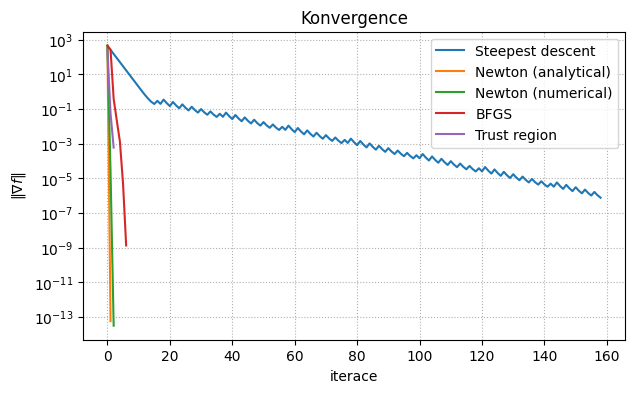

In [38]:
x0 = np.array([-1.2, 1.0])

def run_methods(x0):
    results = []

    # wrapper to count function evaluations (do not shadow the global `fun` objective)
    fun_counted = Counter(fun)

    fun_counted.reset()
    x_sd, hist_sd = steepest_descent(fun_counted, grad_f, x0)
    results.append(("Steepest descent", x_sd, hist_sd, fun_counted.n))

    fun_counted.reset()
    x_na, hist_na = newton(fun_counted, grad_f, hess_f, x0)
    results.append(("Newton (analytical)", x_na, hist_na, fun_counted.n))

    fun_counted.reset()
    x_nn, hist_nn = newton(
        fun_counted,
        lambda x: num_grad(fun_counted, x),
        lambda x: num_hess(fun_counted, x),
        x0,
    )
    results.append(("Newton (numerical)", x_nn, hist_nn, fun_counted.n))

    fun_counted.reset()
    x_bfgs, hist_bfgs = bfgs(fun_counted, grad_f, x0)
    results.append(("BFGS", x_bfgs, hist_bfgs, fun_counted.n))

    fun_counted.reset()
    x_tr, hist_tr = trust_region(fun_counted, grad_f, hess_f, x0)
    results.append(("Trust region", x_tr, hist_tr, fun_counted.n))

    return results

res = run_methods(x0)

print("x0 =", x0)
for name, x_star, hist, n_f_calls in res:
    iters = len(hist["f"]) - 1
    print(f"{name:16s}  it={iters:4d}  n_f_calls={n_f_calls:6d}  f={hist['f'][-1]:.3e}  ||g||={hist['gn'][-1]:.3e}  x={x_star}")

plt.figure(figsize=(7, 4))
for name, _, hist, _ in res:
    plt.semilogy(hist["gn"], label=name)
plt.xlabel("iterace")
plt.ylabel(r"$\|\nabla f\|$")
plt.title("Konvergence")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()

x0 = [ 1.  -0.5]
Steepest descent  it= 193  n_f_calls=  1862  f=1.880e-14  ||g||=7.923e-07  x=[ 1.         -0.99999993]
Newton (analytical)  it=   9  n_f_calls=    66  f=5.866e-17  ||g||=3.099e-08  x=[ 1. -1.]
Newton (numerical)  it=   9  n_f_calls=   187  f=5.864e-17  ||g||=3.099e-08  x=[ 1. -1.]
BFGS              it=   9  n_f_calls=    36  f=9.406e-18  ||g||=1.246e-08  x=[ 1. -1.]
Trust region      it=   6  n_f_calls=    22  f=7.041e-11  ||g||=4.374e-05  x=[ 0.99999994 -1.00000416]


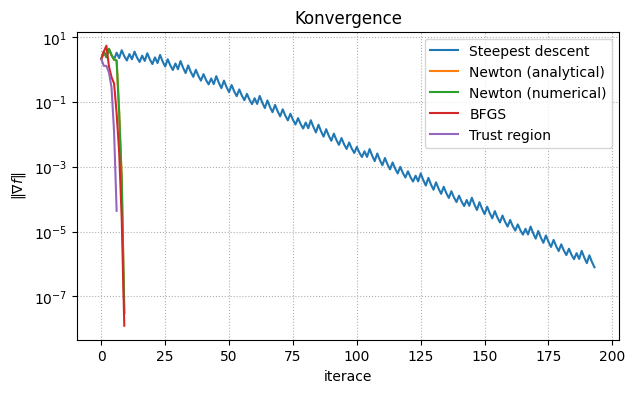

In [39]:
x0 = np.array([1.0, -0.5])


res = run_methods(x0)

print("x0 =", x0)
for name, x_star, hist, n_f_calls in res:
    iters = len(hist["f"]) - 1
    print(f"{name:16s}  it={iters:4d}  n_f_calls={n_f_calls:6d}  f={hist['f'][-1]:.3e}  ||g||={hist['gn'][-1]:.3e}  x={x_star}")

plt.figure(figsize=(7, 4))
for name, _, hist, _ in res:
    plt.semilogy(hist["gn"], label=name)
plt.xlabel("iterace")
plt.ylabel(r"$\|\nabla f\|$")
plt.title("Konvergence")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()

### Závěr

Všechny metody zkonvergovaly k řešení, metoda největšího spádu si však vedla hůř v porovnání s ostatními metodami. Norma gradientu byla nastavena u všech metod na $10^-6$, avšak u některých metod (např. trust region), algoritmus skončil kvůli malé délce kroku $d_k$.

V grafu a z výpočtů lze vidět, že funkce má dvě globální minima v bodech $(1,1)$ a $(1,-1)$ (s hodnotou $f=0$).

## Úloha 2: Optimalizace s omezeními

Vyřešte úlohu s omezeními na rovnost a nerovnost
$$\min_{(x,y) \in \Omega} (x - y)$$

$$\Omega = \{ (x, y) \in \mathbb{R}^2 : x^2 + y^2 = 4 \land x^2 - 2x + y^2 \leq 0 \}$$

pomocí metody penalty nebo nebo rozšířených lagrangiánů.

Zapište Karush-Kuhn-Tuckerovy podmínky pro výše uvedenou úlohu v bodě (2, 0) a rozhodněte,
zda jsou splněny.

### Přípustná množina
Nerovnost
$$(x^2-2x+y^2)\le 0$$
lze upravit na
$$(x-1)^2+y^2\le 1,$$
tj. disk se středem v $(1,0)$ a poloměrem $1$.
$$x^2+y^2=4$$
je kružnice se středem v $(0,0)$ a poloměrem $2$.
Na kružnici platí
$$(x-1)^2+y^2 = x^2-2x+1+y^2 = 5-2x \le 1 \;\Rightarrow\; x\ge 2.$$
Zároveň z $x^2+y^2=4$ plyne $x\le 2$, takže nutně $x=2$ a $y=0$.
Proto je přípustná množina jen bod $(2,0)$.

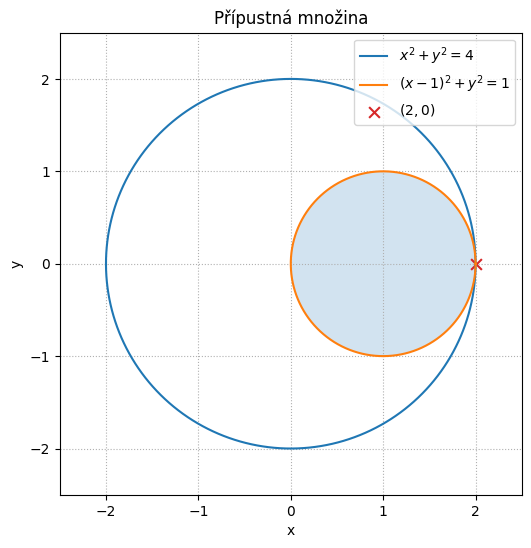

In [40]:
# vizualizace omezení
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

t = np.linspace(0, 2*np.pi, 800)

# boundary of circle x^2+y^2=4
xc = 2*np.cos(t)
yc = 2*np.sin(t)

# boundary of disk (x-1)^2+y^2=1
xd = 1 + np.cos(t)
yd = np.sin(t)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(xc, yc, label=r"$x^2+y^2=4$")
ax.plot(xd, yd, label=r"$(x-1)^2+y^2=1$")

# fill the disk
disk = Circle((1.0, 0.0), 1.0, alpha=0.2)
ax.add_patch(disk)

# feasible set intersection point
ax.scatter([2.0], [0.0], color="tab:red", s=60, marker="x", label="$(2,0)$")

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.grid(True, ls=":")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Přípustná množina")
ax.legend()
plt.show()

In [41]:
def obj2(z):
    x, y = z
    return x - y

def h2(z):
    x, y = z
    return x**2 + y**2 - 4.0

def g2(z):
    x, y = z
    return x**2 - 2.0 * x + y**2

def penalty_solve(z0, rho0=1.0, rho_mult=10.0, max_outer=10, tol_constr=1e-8):
    # pocatecni bod a rho
    z = np.asarray(z0, dtype=float)
    rho = float(rho0)
    outer = []
    for _ in range(max_outer):
        # penalizacni funkce
        def P(w):
            hz = h2(w)
            gz = g2(w)
            return obj2(w) + 0.5 * rho * hz**2 + 0.5 * rho * max(0.0, gz)**2

        P_counted = Counter(P)
        # minimize the penalty function
        z, hist = bfgs(P_counted, lambda w: num_grad(P_counted, w), z, tol_g=1e-8, tol_step=1e-10, max_iter=4000)
        # check constraint violation
        viol = max(abs(h2(z)), max(0.0, g2(z)))
        outer.append((rho, z.copy(), obj2(z), h2(z), g2(z), len(hist["f"]) - 1, P_counted.n, viol))
        if viol <= tol_constr:
            break
        # update rho to a larger value
        rho *= rho_mult
    return z, outer

z0 = np.array([1.0, 1.0])
z_star, outer = penalty_solve(z0)

print("z0 =", z0)
for rho, z, fval, hval, gval, iters, n_f_calls, viol in outer:
    print(f"rho={rho:9.1e}  it={iters:4d}  nfev={n_f_calls:6d}  z={z}  f={fval:.6f}  h={hval:.3e}  g={gval:.3e}  viol={viol:.3e}")

print("\nVýsledek:")
print("z* =", z_star)
print("f(z*) =", obj2(z_star))
print("h(z*) =", h2(z_star))
print("g(z*) =", g2(z_star))


z0 = [1. 1.]
rho=  1.0e+00  it=  10  nfev=    78  z=[1.23349035 1.37610469]  f=-0.142614  h=-5.848e-01  g=9.482e-01  viol=9.482e-01
rho=  1.0e+01  it=   9  nfev=    79  z=[1.85068607 0.68000838]  f=1.170678  h=-1.125e-01  g=1.861e-01  viol=1.861e-01
rho=  1.0e+02  it=  12  nfev=   105  z=[1.97103553 0.30692006]  f=1.664115  h=-2.082e-02  g=3.711e-02  viol=3.711e-02
rho=  1.0e+03  it=  14  nfev=   140  z=[1.99413177 0.13916427]  f=1.854968  h=-4.072e-03  g=7.665e-03  viol=7.665e-03
rho=  1.0e+04  it=  12  nfev=   119  z=[1.99877479 0.06376652]  f=1.935008  h=-8.331e-04  g=1.617e-03  viol=1.617e-03
rho=  1.0e+05  it=  11  nfev=   111  z=[1.99974002 0.02940889]  f=1.970331  h=-1.750e-04  g=3.450e-04  viol=3.450e-04
rho=  1.0e+06  it=  10  nfev=   131  z=[1.99994439 0.0136087 ]  f=1.986336  h=-3.724e-05  g=7.398e-05  viol=7.398e-05
rho=  1.0e+07  it=  12  nfev=   134  z=[1.99998806 0.00630752]  f=1.993681  h=-7.977e-06  g=1.590e-05  viol=1.590e-05
rho=  1.0e+08  it=  12  nfev=   140  z=[1.

***KKT podmnínky v bodě (2,0)***
$$\nabla f(x,y) = \begin{pmatrix}1\\-1\end{pmatrix} $$
$$\nabla h(x,y) = \begin{pmatrix}2x\\2y\end{pmatrix} $$
$$\nabla g(x,y) = \begin{pmatrix}2x-2\\2y\end{pmatrix} $$
$$\nabla f(2,0) = \begin{pmatrix}1\\-1\end{pmatrix} $$
$$\nabla h(2,0) = \begin{pmatrix}4\\0\end{pmatrix} $$
$$\nabla g(2,0) = \begin{pmatrix}2\\0\end{pmatrix} $$

KKT:
- $$ \begin{pmatrix}1\\-1\end{pmatrix} + \lambda \begin{pmatrix}4\\0\end{pmatrix} + \mu \begin{pmatrix}2\\0\end{pmatrix} = \begin{pmatrix}0\\0\end{pmatrix}$$
- $$ x^2 + y^2 = 4$$
- $$\mu \geq 0$$
- $$\mu (x^2 -2x + y^2) = 0$$

Z y složky první rovnice vidíme, že $$-1 +\lambda \cdot 0 + \mu \cdot 0 = -1 = 0,$$ tudíž KKT podmínky nejsou splněny.

